# Initialisation

* `src()` works well in the previous workflow whereas the current call does not (with yellow wave under the functions which actually are called).

In [ ]:
year          = 2023
loc_json = "json/location_params.json"
geo_json      = 'json/geo_params.json'
default_json  = 'json/default_params.json'
config_json   = 'json/UQ_null.json'
epw_path      = '../src/_base/epw/ED-TMYx.2023.epw'
occupancyProfile_csv = 'ETHlib/auxiliary/schedules_el_OFFICE.csv'

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import json

ROOT = Path.cwd().parent.resolve()
RC_SIMULATOR = "ETHlib"
if str(RC_SIMULATOR) not in sys.path:
    sys.path.insert(0, str(RC_SIMULATOR))

from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system
from radiation import Location, Window

CITYLOC       = json.loads(Path(loc_json).read_text())
latitude_deg = CITYLOC['latitude_deg']
longitude_deg  = CITYLOC['longitude_deg']
EDI            = Location(epwfile_path=epw_path)
GEOMETRY       = json.loads(Path(geo_json).read_text())
DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
occupancyProfile = pd.read_csv(occupancyProfile_csv)

In [4]:
meter_path = "_data/Metering_ISO.csv"
meter_daily = load_meter_heating(meter_path, "Main Heating", GEOMETRY["FLOOR_AREA"], "D")
meter_hourly = load_meter_heating(meter_path, "Main Heating", GEOMETRY["FLOOR_AREA"], "h")

Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00


# ETH_package

* Ventilation is not calculated as an airflow network. It is simplified into a single heat-loss conductance between indoor air and supply/outdoor air
* Parameter definition
    * "_alpha"     :     3,   # coefficient for 'area of surfaces facing the room'
    * "_beta"      :     0.3, # coefficient for 'south windows'

In [ ]:
def run_model(
    sampled_params,
    controller_mode="occupancy",
    occupancy_controller_params=None,
):
    p = merge_params(sampled_params, DEFAULT_PARAMS)

    HeatingDemand, HeatingEnergy, CoolingDemand, CoolingEnergy = [], [], [], []
    ElectricityOut, IndoorAir, OutsideTemp, SolarGains, COP = [], [], [], [], []
    ach_vent_hourly, ach_infl_hourly, h_ve_adj_hourly = [], [], []

    t_m_prev = 20.0

    heating_schedule = make_heating_schedule(year=year, p=p)

    ach_vent_baseline, ach_infl_baseline = make_ach(
        p=p,
        geometry=GEOMETRY,
        calc_ach=calc_ach,
    )

    base_occupancy_controller_params = {
        "n_people": p["max_occupancy"],
        "ach_vent_baseline": ach_vent_baseline,
    }

    if occupancy_controller_params is not None:
        base_occupancy_controller_params.update(occupancy_controller_params)

    occupancy_controller_params = base_occupancy_controller_params

    Office = make_zone(
        p=p,
        geometry=GEOMETRY,
        ach_vent=ach_vent_baseline,
        ach_infl=ach_infl_baseline,
        Zone=Zone,
        supply_system=supply_system,
        emission_system=emission_system,
    )

    SouthWindow = Window(
        azimuth_tilt=0,
        alititude_tilt=90,
        glass_solar_transmittance=0.7,
        glass_light_transmittance=0.8,
        area=GEOMETRY["WINDOW_AREA"] * p["_beta"],
    )

    for hour in range(8760):
        occupancy = occupancyProfile.loc[hour, "People"] * p["max_occupancy"]

        if controller_mode == "original":
            desired_ach = ach_vent_baseline

        elif controller_mode == "occupancy":
            desired_ach = occupancy_based_ach(
                hour=hour,
                occupancy=occupancy,
                **occupancy_controller_params,
            )

        else:
            raise ValueError(
                f"Unknown controller_mode: {controller_mode}. "
                "Use 'original' or 'occupancy'."
            )

        Office.ach_vent = desired_ach

        ach_vent_hourly.append(Office.ach_vent)
        ach_infl_hourly.append(Office.ach_infl)
        h_ve_adj_hourly.append(Office.h_ve_adj)

        Office.t_set_heating = heating_schedule[hour]

        internal_gains = (
            occupancy * p["gain_per_person"]
            + p["appliance_gains"] * Office.floor_area
        )

        t_out = EDI.weather_data["drybulb_C"][hour]

        altitude, azimuth = EDI.calc_sun_position(
            latitude_deg=latitude_deg,
            longitude_deg=longitude_deg,
            year=year,
            hoy=hour,
        )

        SouthWindow.calc_solar_gains(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_radiation=EDI.weather_data["dirnorrad_Whm2"][hour],
            horizontal_diffuse_radiation=EDI.weather_data["difhorrad_Whm2"][hour],
        )

        SouthWindow.calc_illuminance(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_illuminance=EDI.weather_data["dirnorillum_lux"][hour],
            horizontal_diffuse_illuminance=EDI.weather_data["difhorillum_lux"][hour],
        )

        Office.solve_energy(
            internal_gains=internal_gains,
            solar_gains=SouthWindow.solar_gains,
            t_out=t_out,
            t_m_prev=t_m_prev,
        )

        Office.solve_lighting(
            illuminance=SouthWindow.transmitted_illuminance,
            occupancy=occupancy,
        )

        t_m_prev = Office.t_m_next

        fa = GEOMETRY["FLOOR_AREA"]

        HeatingDemand.append(Office.heating_demand / 1000.0 / fa)
        HeatingEnergy.append(Office.heating_energy / 1000.0 / fa)
        CoolingDemand.append(Office.cooling_demand / 1000.0 / fa)
        CoolingEnergy.append(Office.cooling_energy / 1000.0 / fa)
        ElectricityOut.append(Office.electricity_out / 1000.0 / fa)
        IndoorAir.append(Office.t_air)
        OutsideTemp.append(t_out)
        SolarGains.append(SouthWindow.solar_gains)
        COP.append(Office.cop)

    annualResults = pd.DataFrame(
        {
            "HeatingDemand": HeatingDemand,
            "HeatingEnergy": HeatingEnergy,
            "CoolingDemand": CoolingDemand,
            "CoolingEnergy": CoolingEnergy,
            "ElectricityOut": ElectricityOut,
            "IndoorAir": IndoorAir,
            "OutsideTemp": OutsideTemp,
            "SolarGains": SolarGains,
            "COP": COP,
            "ach_vent": ach_vent_hourly,
            "ach_infl": ach_infl_hourly,
            "h_ve_adj": h_ve_adj_hourly,
        },
        index=pd.date_range(f"{year}-01-01", periods=8760, freq="h"),
    )

    annual_EUI = annualResults[["HeatingEnergy", "CoolingEnergy"]].sum()

    return annualResults, annual_EUI, Office

# Test_1

In [6]:
res_orig, eui_orig, _ = run_model(
    sampled_params = {},
    controller_mode="original"
)

res_occ, eui_occ, _ = run_model(
    sampled_params = {},
    controller_mode="occupancy"
)

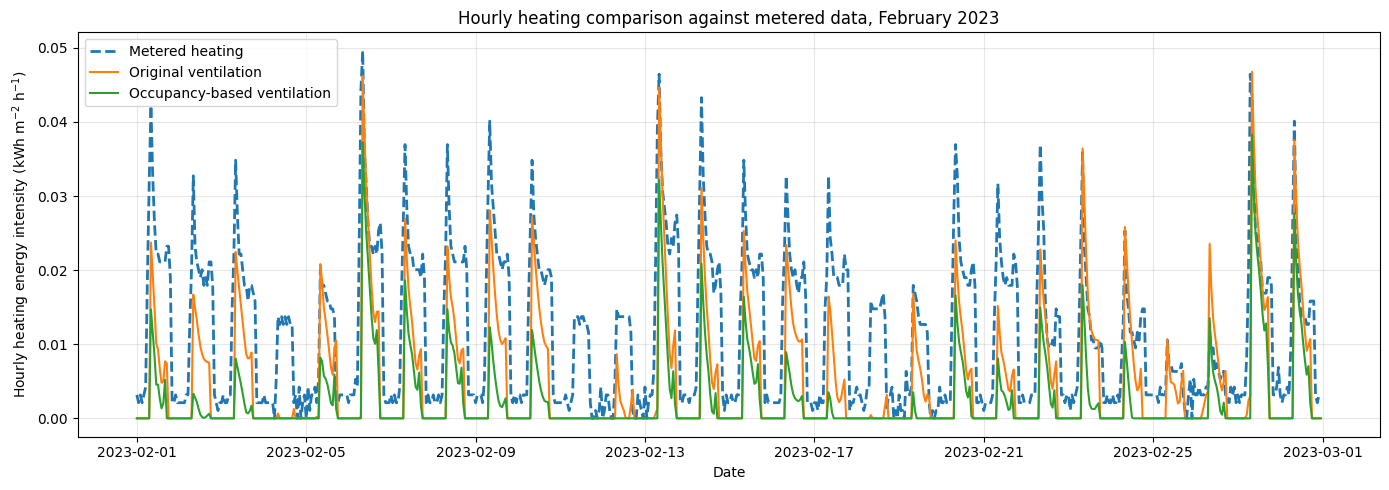

In [7]:
start = "2023-02-01 00:00"
end   = "2023-02-28 23:00"

res_orig_feb = res_orig.loc[start:end].copy()
res_occ_feb  = res_occ.loc[start:end].copy()
meter_feb    = meter_hourly.loc[start:end].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    meter_feb.index,
    meter_feb,
    label="Metered heating",
    linewidth=2.0,
    linestyle="--"
)

plt.plot(
    res_orig_feb.index,
    res_orig_feb["HeatingEnergy"],
    label="Original ventilation",
    linewidth=1.5
)

plt.plot(
    res_occ_feb.index,
    res_occ_feb["HeatingEnergy"],
    label="Occupancy-based ventilation",
    linewidth=1.5
)

plt.ylabel("Hourly heating energy intensity (kWh m$^{-2}$ h$^{-1}$)")
plt.xlabel("Date")
plt.title("Hourly heating comparison against metered data, February 2023")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test-2

In [8]:
occupancy_cases = {
    "occ_1p5_0p5": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.5,
        "occupancy_threshold": 100,
    },
    "occ_1p5_0p3": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.3,
        "occupancy_threshold": 100,
    },
    "occ_1p5_0p1": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.1,
        "occupancy_threshold": 100,
    },
    "occ_1p0_0p3": {
        "occupied_ach": 1.0,
        "unoccupied_ach": 0.3,
        "occupancy_threshold": 100,
    },
    "occ_1p0_0p5": {
        "occupied_ach": 1.0,
        "unoccupied_ach": 0.5,
        "occupancy_threshold": 100,
    },
}

results = {}
euis = {}

# Original constant-ventilation case
results["original"], euis["original"], _ = run_model(
    sampled_params={},
    controller_mode="original",
)

results["occupancy_default"], euis["occupancy_default"], _ = run_model(
    sampled_params={},
    controller_mode="occupancy",
)

for case_name, ctrl_params in occupancy_cases.items():
    results[case_name], euis[case_name], _ = run_model(
        sampled_params={},
        controller_mode="occupancy",
        occupancy_controller_params=ctrl_params,
    )
    
    
comparison = []

for case_name, res in results.items():

    if case_name == "original":
        controller_type = "constant baseline"
        occupied_ach = res["ach_vent"].iloc[0]
        unoccupied_ach = np.nan
        occupancy_threshold = np.nan

    elif case_name == "occupancy_default":
        controller_type = "occupancy default"
        occupied_ach = res["ach_vent"].max()
        unoccupied_ach = res["ach_vent"].min()
        occupancy_threshold = 0.1 * DEFAULT_PARAMS["max_occupancy"]

    else:
        controller_type = "occupancy manual"
        ctrl_params = occupancy_cases[case_name]
        occupied_ach = ctrl_params["occupied_ach"]
        unoccupied_ach = ctrl_params["unoccupied_ach"]
        occupancy_threshold = ctrl_params["occupancy_threshold"]

    comparison.append({
        "case": case_name,
        "controller_type": controller_type,

        # Controller settings or inferred effective values
        "occupied_ach": occupied_ach,
        "unoccupied_ach": unoccupied_ach,
        "occupancy_threshold": occupancy_threshold,

        # Physical ventilation states
        "mean_ach_vent": res["ach_vent"].mean(),
        "min_ach_vent": res["ach_vent"].min(),
        "max_ach_vent": res["ach_vent"].max(),
        "mean_ach_infl": res["ach_infl"].mean(),

        # Energy outcomes
        "heating_eui": res["HeatingEnergy"].sum(),
        "cooling_eui": res["CoolingEnergy"].sum(),
        "total_hvac_eui": (
            res["HeatingEnergy"].sum()
            + res["CoolingEnergy"].sum()
        ),
    })

comparison_df = pd.DataFrame(comparison).set_index("case")

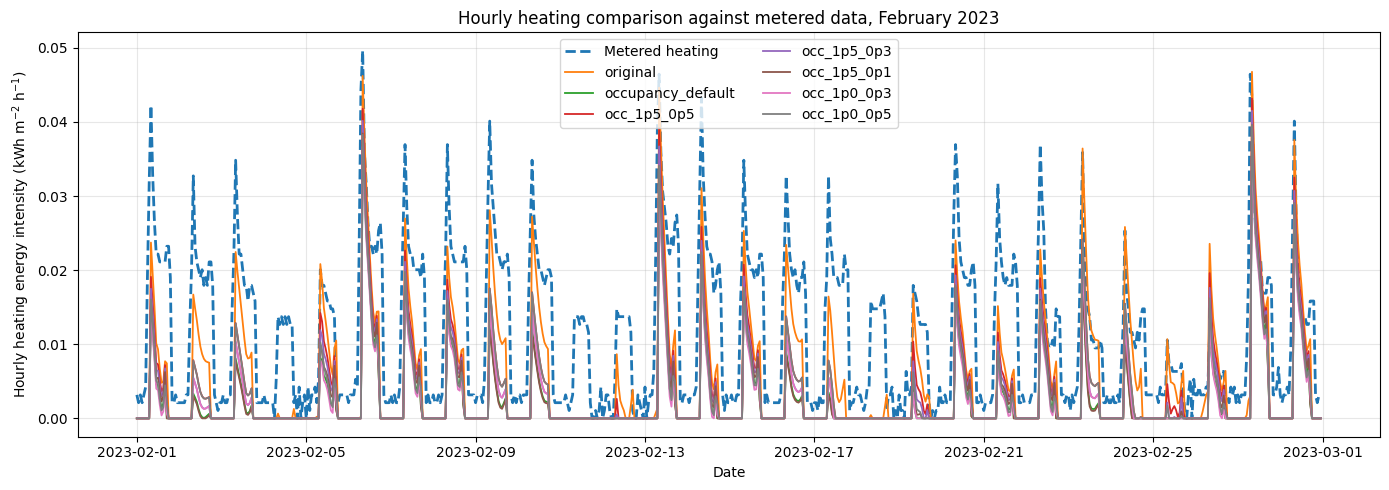

In [9]:
start = "2023-02-01 00:00"
end   = "2023-02-28 23:00"

meter_feb = meter_hourly.loc[start:end].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    meter_feb.index,
    meter_feb,
    label="Metered heating",
    linewidth=2.0,
    linestyle="--",
)

for case_name, res in results.items():
    res_feb = res.loc[start:end].copy()

    plt.plot(
        res_feb.index,
        res_feb["HeatingEnergy"],
        label=case_name,
        linewidth=1.3,
    )

plt.ylabel(r"Hourly heating energy intensity (kWh m$^{-2}$ h$^{-1}$)")
plt.xlabel("Date")
plt.title("Hourly heating comparison against metered data, February 2023")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()